In [1]:
import pandas as pd
import keras
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, f1_score,
    precision_score, recall_score,
    accuracy_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import calibration_curve
from tensorflow.keras.models import clone_model


pd.set_option("display.max_columns", None)

## Read Data

In [2]:
filepath = 'Particle Physics Event Classification.csv'
df = pd.read_csv(filepath)

df.replace(-999, 0, inplace = True) # 0 is a valid number for "non-observed" jets; physically meaningful absence

# Add indicators for missing leading and/or subleading jets
df['missing_leading'] = np.where(df['PRI_jet_num'] == 0, 1, 0)
df['missing_subleading'] = np.where(df['PRI_jet_num'].isin([1, 0]), 1, 0)

df

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_tau,DER_met_phi_centrality,DER_lep_eta_centrality,PRI_tau_pt,PRI_tau_eta,PRI_tau_phi,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_met,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,missing_leading,missing_subleading
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,1.582,1.396,0.2,32.638,1.017,0.381,51.626,2.273,-2.414,16.824,-0.277,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s,0,0
1,100001,160.937,68.768,103.235,48.146,0.00,0.000,0.000,3.473,2.078,125.157,0.879,1.414,0.0,42.014,2.039,-3.011,36.918,0.501,0.103,44.704,-1.916,164.546,1,46.226,0.725,1.158,0.000,0.00,0.000,46.226,2.233584,b,0,1
2,100002,0.000,162.172,125.953,35.635,0.00,0.000,0.000,3.148,9.336,197.814,3.776,1.414,0.0,32.154,-0.705,-2.093,121.409,-0.953,1.052,54.283,-2.186,260.414,1,44.251,2.053,-2.028,0.000,0.00,0.000,44.251,2.347389,b,0,1
3,100003,143.905,81.417,80.943,0.414,9.00,0.000,0.000,3.310,0.414,75.968,2.354,-1.285,0.0,22.647,-1.655,0.010,53.321,-0.522,-3.100,31.082,0.060,86.062,0,0.000,0.000,0.000,0.000,0.00,0.000,0.000,5.446378,b,1,1
4,100004,175.864,16.915,134.805,16.405,0.00,0.000,0.000,3.891,16.405,57.983,1.056,-1.385,0.0,28.209,-2.197,-2.231,29.774,0.798,1.569,2.723,-0.871,53.131,0,0.000,0.000,0.000,0.000,0.00,0.000,0.000,6.245333,b,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,349995,0.000,71.989,36.548,5.042,0.00,0.000,0.000,1.392,5.042,55.892,1.258,-1.414,0.0,24.754,-0.414,-0.905,31.137,-0.950,0.380,46.520,2.859,144.665,0,0.000,0.000,0.000,0.000,0.00,0.000,0.000,4.505083,b,1,1
249996,349996,0.000,58.179,68.083,22.439,0.00,0.000,0.000,2.585,22.439,50.618,1.162,-1.345,0.0,23.416,-1.609,2.776,27.202,0.308,1.042,46.737,-0.867,80.408,0,0.000,0.000,0.000,0.000,0.00,0.000,0.000,2.497259,b,1,1
249997,349997,105.457,60.526,75.839,39.757,0.00,0.000,0.000,2.390,22.183,120.462,1.202,0.529,0.0,35.636,-0.266,-3.132,42.834,0.381,0.851,23.419,-2.890,198.907,1,41.992,1.800,-0.166,0.000,0.00,0.000,41.992,0.018636,s,0,1
249998,349998,94.951,19.362,68.812,13.504,0.00,0.000,0.000,3.365,13.504,55.859,0.999,1.414,0.0,27.944,-2.211,2.792,27.915,-0.874,-0.296,12.150,0.811,112.718,0,0.000,0.000,0.000,0.000,0.00,0.000,0.000,1.681611,b,1,1


In [ ]:
X = df.drop(columns = ['EventId', 'Weight', 'Label'])
y = df['Label'].map({'b': 0, 's': 1})

not_needed_cols = ['EventId', 'Weight', 'Label']
feature_cols = [c for c in df.columns if c not in not_needed_cols]

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)

# Define sample_weight score to pun
classes = np.unique(y_train)
weights = compute_class_weight(class_weight = 'balanced', classes = classes, y = y_train)

class_weights = dict(zip(classes, weights))

In [4]:
# Reference Cell
print(class_weights)

{np.int64(0): np.float64(0.7620340415847057), np.int64(1): np.float64(1.454074510655458)}


In [ ]:
### BUILD MODEL

def build_model(hp):
    model = keras.Sequential()

    num_layers = hp.Int("num_layers", min_value = 1, max_value = 4)
    initializer = hp.Choice("kernel_initializer", ["he_normal", "glorot_uniform"])

    for i in range(num_layers): # Loop to experiment with deepness of NN
        units = hp.Int(
            f"units_{i}",
            min_value = 32,
            max_value = 512,
            step = 32
        )

        # Per-layer L2
        l2_val = hp.Float(f"l2_{i}", 1e-5, 1e-2, sampling = "log")

        model.add(
            keras.layers.Dense(
                units = units,
                activation = "relu",
                kernel_initializer = initializer,
                kernel_regularizer = keras.regularizers.l2(l2_val)
            )
        )

        # Batch norm before dropout
        if hp.Boolean(f"use_batchnorm_{i}"):
            model.add(keras.layers.BatchNormalization())

        if hp.Boolean(f"use_dropout_{i}"):
            model.add(
                keras.layers.Dropout(
                    rate = hp.Float(f"dropout_rate_{i}", 0.1, 0.5, step = 0.1)
                )
            )

    model.add(keras.layers.Dense(1, activation = "sigmoid")) # Output layer

    learning_rate = hp.Float("learning_rate", 1e-4, 1e-2, sampling = "log")

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate = learning_rate),
        loss = "binary_crossentropy",
        metrics = [keras.metrics.AUC(name="auc")]
    )

    return model


### Keras tuner for hyperparams

tuner = kt.BayesianOptimization(
    build_model,
    objective = kt.Objective("val_auc", direction="max"),
    max_trials = 40, # 40 TRIALS FOR BEST MODEL
    num_initial_points = 12, 
    directory = "keras_tuning",
    project_name = "nn_particlePHYS"
)

early_stop = keras.callbacks.EarlyStopping(
    monitor = "val_auc",
    patience = 8,
    restore_best_weights = True,
    mode = "max"
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor = "val_auc",
    factor = 0.5,
    patience = 4,
    min_lr = 1e-6,
    mode = "max",
    verbose = 0
)

### Search for best model

tuner.search(
    X_train_scaled,
    y_train,
    validation_split = 0.2,
    epochs = 150,
    batch_size = 256,
    class_weight = class_weights,
    callbacks = [early_stop, reduce_lr],
    verbose = 1
)

best_model = tuner.get_best_models(num_models = 1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("\nBest hyperparameters:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")


### Predict
y_prob = best_model.predict(X_test_scaled).flatten()

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

print(f"\nTest ROC-AUC : {roc_auc:.4f}")
print(f"Test PR-AUC  : {pr_auc:.4f}")

Trial 40 Complete [00h 03m 18s]
val_auc: 0.9113189578056335

Best val_auc So Far: 0.9119600057601929
Total elapsed time: 01h 42m 52s

Best hyperparameters:
  num_layers: 4
  kernel_initializer: glorot_uniform
  units_0: 480
  l2_0: 0.01
  use_batchnorm_0: True
  use_dropout_0: True
  learning_rate: 0.0001
  units_1: 352
  l2_1: 0.01
  use_batchnorm_1: True
  use_dropout_1: True
  units_2: 32
  l2_2: 1e-05
  use_batchnorm_2: True
  use_dropout_2: False
  units_3: 32
  l2_3: 0.005178092397084918
  use_batchnorm_3: True
  use_dropout_3: True
  dropout_rate_1: 0.30000000000000004
  dropout_rate_0: 0.5
  dropout_rate_2: 0.4
  dropout_rate_3: 0.1
  45/1954 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step   

c:\Users\nicho\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1954/1954 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Test ROC-AUC : 0.9131
Test PR-AUC  : 0.8546


Threshold : 0.532
Accuracy  : 0.8367
Precision : 0.7337
Recall    : 0.8138
F1        : 0.7716
ROC AUC   : 0.9131


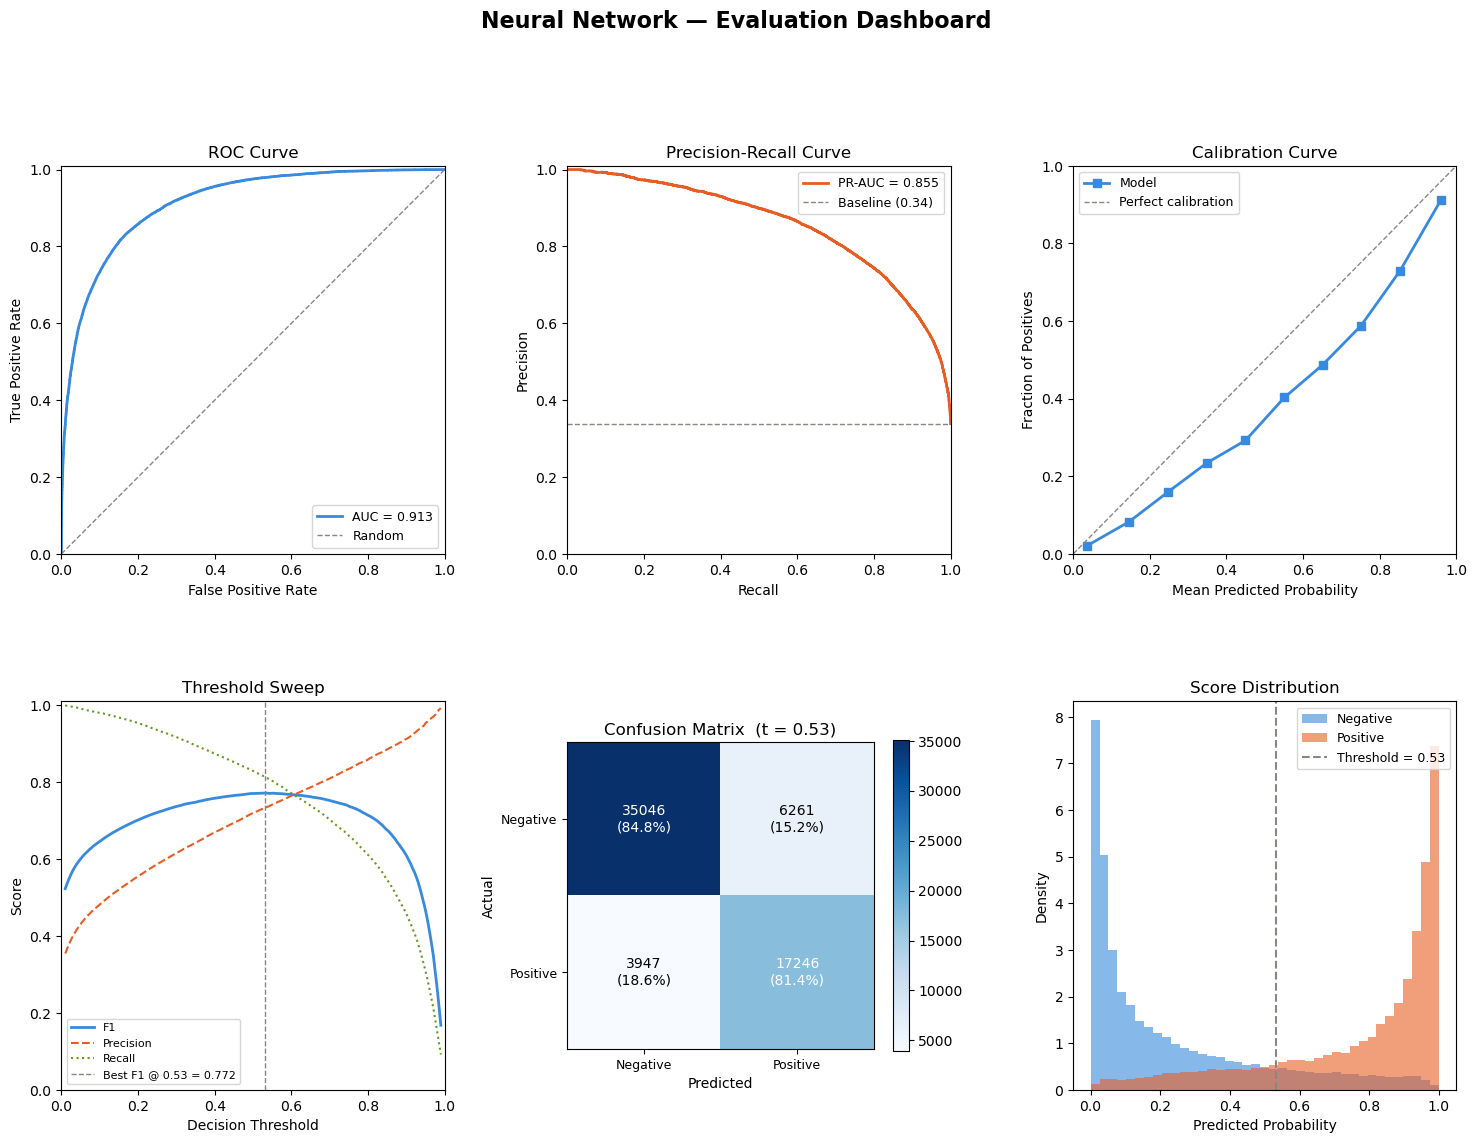


Plot saved → nn_evaluation_dashboard.png


In [ ]:
### Eval

thresholds = np.linspace(0.01, 0.99, 200)
f1_scores = [f1_score(y_test, y_prob >= t, zero_division = 0) for t in thresholds]
prec_scores = [float(np.mean((y_prob >= t) == y_test) if (y_prob >= t).any() else 0) for t in thresholds]

# More principled precision per threshold
prec_scores = [precision_score(y_test, y_prob >= t, zero_division = 0) for t in thresholds]
rec_scores = [recall_score(y_test, y_prob >= t, zero_division = 0)    for t in thresholds]

best_thresh_idx = int(np.argmax(f1_scores))
best_thresh = thresholds[best_thresh_idx]
y_pred = (y_prob >= best_thresh).astype(int)

print(f"Threshold : {best_thresh:.3f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, zero_division = 0):.4f}")
print(f"Recall : {recall_score(y_test, y_pred, zero_division = 0):.4f}")
print(f"F1 : {f1_score(y_test, y_pred, zero_division = 0):.4f}")
print(f"ROC AUC : {roc_auc_score(y_test, y_prob):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins = 10)
cm = confusion_matrix(y_test, y_pred)

### DEFINE DB LAYOUT
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Neural Network - Evaluation Dashboard", fontsize = 16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, figure = fig, hspace = 0.38, wspace = 0.32)

ax1 = fig.add_subplot(gs[0, 0])   # ROC
ax2 = fig.add_subplot(gs[0, 1])   # PR curve
ax3 = fig.add_subplot(gs[0, 2])   # Calibration
ax4 = fig.add_subplot(gs[1, 0])   # Threshold sweep
ax5 = fig.add_subplot(gs[1, 1])   # Confusion matrix
ax6 = fig.add_subplot(gs[1, 2])   # Score distribution

BLUE   = "#378ADD"
ORANGE = "#E85D24"
GREEN  = "#639922"
GRAY   = "#888780"

# ROC CURVE
ax1.plot(fpr, tpr, color = BLUE, lw = 2, label = f"AUC = {roc_auc:.3f}")
ax1.plot([0, 1], [0, 1], "--", color = GRAY, lw = 1, label = "Random")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.legend(loc = "lower right", fontsize = 9)
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.01])

### PREC-RECALL CURVE
baseline = float(y_test.mean())
ax2.plot(recall, precision, color = ORANGE, lw = 2, label = f"PR-AUC = {pr_auc:.3f}")
ax2.axhline(baseline, color = GRAY, lw = 1, linestyle = "--", label = f"Baseline ({baseline:.2f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend(loc = "upper right", fontsize = 9)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.01])

### CALIBRATION CURVE
ax3.plot(mean_pred, frac_pos, "s-", color = BLUE, lw = 2, label = "Model")
ax3.plot([0, 1], [0, 1], "--", color = GRAY, lw = 1, label = "Perfect calibration")
ax3.set_xlabel("Mean Predicted Probability")
ax3.set_ylabel("Fraction of Positives")
ax3.set_title("Calibration Curve")
ax3.legend(loc = "upper left", fontsize = 9)
ax3.set_xlim([0, 1]); ax3.set_ylim([0, 1])

### THRESH SWEEP
ax4.plot(thresholds, f1_scores,   color = BLUE,   lw = 2, label = "F1")
ax4.plot(thresholds, prec_scores, color = ORANGE, lw = 1.5, linestyle = "--", label = "Precision")
ax4.plot(thresholds, rec_scores,  color = GREEN,  lw = 1.5, linestyle = ":",  label = "Recall")
ax4.axvline(best_thresh, color = GRAY, lw = 1, linestyle = "--", label = f"Best F1 @ {best_thresh:.2f} = {f1_scores[best_thresh_idx]:.3f}")
ax4.set_xlabel("Decision Threshold")
ax4.set_ylabel("Score")
ax4.set_title("Threshold Sweep")
ax4.legend(fontsize = 8)
ax4.set_xlim([0, 1]); ax4.set_ylim([0, 1.01])

### CONFUSION MATRIX
im = ax5.imshow(cm, interpolation = "nearest", cmap = "Blues")
fig.colorbar(im, ax = ax5, shrink = 0.8)
classes = ["Negative", "Positive"]
tick_marks = np.arange(len(classes))
ax5.set_xticks(tick_marks); ax5.set_xticklabels(classes, fontsize = 9)
ax5.set_yticks(tick_marks); ax5.set_yticklabels(classes, fontsize = 9)
ax5.set_xlabel("Predicted"); ax5.set_ylabel("Actual")
ax5.set_title(f"Confusion Matrix  (t = {best_thresh:.2f})")
cm_norm = cm.astype(float) / cm.sum(axis = 1, keepdims = True)
for i in range(2):
    for j in range(2):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax5.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.1%})", ha = "center", va = "center", color = color, fontsize = 10)

### SCORE DISTRIBUTION
neg_probs = y_prob[y_test == 0]
pos_probs = y_prob[y_test == 1]
bins = np.linspace(0, 1, 40)
ax6.hist(neg_probs, bins = bins, alpha = 0.6, color = BLUE,   density = True, label = "Negative")
ax6.hist(pos_probs, bins = bins, alpha = 0.6, color = ORANGE, density = True, label = "Positive")
ax6.axvline(best_thresh, color = GRAY, lw = 1.5, linestyle = "--",label = f"Threshold = {best_thresh:.2f}")
ax6.set_xlabel("Predicted Probability")
ax6.set_ylabel("Density")
ax6.set_title("Score Distribution")
ax6.legend(fontsize = 9)

plt.savefig("nn_evaluation_dashboard.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("\nPlot saved → nn_evaluation_dashboard.png")

In [ ]:
# best_model.save("best_model_NN.keras")
best_model = keras.models.load_model("best_model_NN.keras") # Load model to skip retraining

# Recreate variables (after environment restart)
best_hp = kt.HyperParameters()

# Global hyperparameters
best_hp.values["num_layers"] = 4
best_hp.values["kernel_initializer"] = "glorot_uniform"
best_hp.values["learning_rate"] = 0.0001

# Layer 0
best_hp.values["units_0"] = 480
best_hp.values["l2_0"] = 0.01
best_hp.values["use_batchnorm_0"] = True
best_hp.values["use_dropout_0"] = True
best_hp.values["dropout_rate_0"] = 0.5

# Layer 1
best_hp.values["units_1"] = 352
best_hp.values["l2_1"] = 0.01
best_hp.values["use_batchnorm_1"] = True
best_hp.values["use_dropout_1"] = True
best_hp.values["dropout_rate_1"] = 0.3

# Layer 2
best_hp.values["units_2"] = 32
best_hp.values["l2_2"] = 1e-05
best_hp.values["use_batchnorm_2"] = True
best_hp.values["use_dropout_2"] = False
best_hp.values["dropout_rate_2"] = 0.4

# Layer 3
best_hp.values["units_3"] = 32
best_hp.values["l2_3"] = 0.005178092397084918
best_hp.values["use_batchnorm_3"] = True
best_hp.values["use_dropout_3"] = True
best_hp.values["dropout_rate_3"] = 0.1

# Verify
print(best_hp.values)

early_stop = keras.callbacks.EarlyStopping(
    monitor = "val_auc",
    patience = 8,
    restore_best_weights = True,
    mode = "max"
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor = "val_auc",
    factor = 0.5,
    patience = 4,
    min_lr = 1e-6,
    mode = "max",
    verbose = 0
)

{'num_layers': 4, 'kernel_initializer': 'glorot_uniform', 'learning_rate': 0.0001, 'units_0': 480, 'l2_0': 0.01, 'use_batchnorm_0': True, 'use_dropout_0': True, 'dropout_rate_0': 0.5, 'units_1': 352, 'l2_1': 0.01, 'use_batchnorm_1': True, 'use_dropout_1': True, 'dropout_rate_1': 0.3, 'units_2': 32, 'l2_2': 1e-05, 'use_batchnorm_2': True, 'use_dropout_2': False, 'dropout_rate_2': 0.4, 'units_3': 32, 'l2_3': 0.005178092397084918, 'use_batchnorm_3': True, 'use_dropout_3': True, 'dropout_rate_3': 0.1}


c:\Users\nicho\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Soft Hard Negative Mining on `best_model`

In [ ]:
# Pre-split data again to prevent data leakage
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size = 0.2,
    random_state = 2026,
    stratify = y_train
)

# Clone and compile
best_model_shnm = clone_model(best_model)
best_model_shnm.set_weights(best_model.get_weights())
best_model_shnm.compile(
    optimizer = keras.optimizers.Adam(best_hp.get("learning_rate")),
    loss = "binary_crossentropy",
    metrics = [keras.metrics.AUC(name="auc")]
)

# Score ONLY the training portion — validation samples never touched here
p_train = best_model_shnm.predict(X_tr, batch_size = 4096).flatten()
y_tr_np = np.asarray(y_tr).astype(int)

# Soft hard-negative sample weights
lambda_factor = 2.0
gamma = 2.0

sample_weight = np.ones_like(p_train, dtype = np.float32)

neg_mask = (y_tr_np == 0)
sample_weight[neg_mask] = 1.0 + lambda_factor * (p_train[neg_mask] ** gamma)

# Apply class weights
sample_weight[y_tr_np == 1] *= float(class_weights[1])
sample_weight[y_tr_np == 0] *= float(class_weights[0])

print("Sample weight summary - min: {:.4f}  mean: {:.4f}  max: {:.4f}".format(np.min(sample_weight), np.mean(sample_weight), np.max(sample_weight)))

early_stop_shnm = keras.callbacks.EarlyStopping(
    monitor = "val_auc",
    patience = 8,
    restore_best_weights = True,
    mode = "max"
)

history_shnm = best_model_shnm.fit(
    X_tr,
    y_tr,
    sample_weight = sample_weight,
    validation_data = (X_val, y_val),
    epochs = 50,
    batch_size = 256,
    callbacks = [early_stop_shnm, reduce_lr],
    verbose = 1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Sample weight summary — min: 0.7620  mean: 1.1135  max: 2.2795
Epoch 1/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - auc: 0.9028 - loss: 0.5350 - val_auc: 0.9080 - val_loss: 0.3925 - learning_rate: 1.0000e-04
Epoch 2/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9034 - loss: 0.5346 - val_auc: 0.9078 - val_loss: 0.3926 - learning_rate: 1.0000e-04
Epoch 3/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9030 - loss: 0.5369 - val_auc: 0.9080 - val_loss: 0.3922 - learning_rate: 1.0000e-04
Epoch 4/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9038 - loss: 0.5355 - val_auc: 0.9088 - val_loss: 0.3911 - learning_rate: 1.0000e-04
Epoch 5/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9037 - loss: 0.5359 - val_auc: 0.9076 - val_loss: 0.3933 - learning_rate: 1.0000e-04
Epoch 6/50
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9037 - loss: 0.5363 - val_auc: 0.9051 - val_loss: 0.3955 - learning_rate: 1.0000e-04
Epoch 7/50
586/586 ━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Test ROC-AUC : 0.9129
Test PR-AUC  : 0.8538

Best threshold (max F1): 0.424
Accuracy  : 0.8375
Precision : 0.7384
Recall    : 0.8064
F1        : 0.7709
ROC AUC   : 0.9129


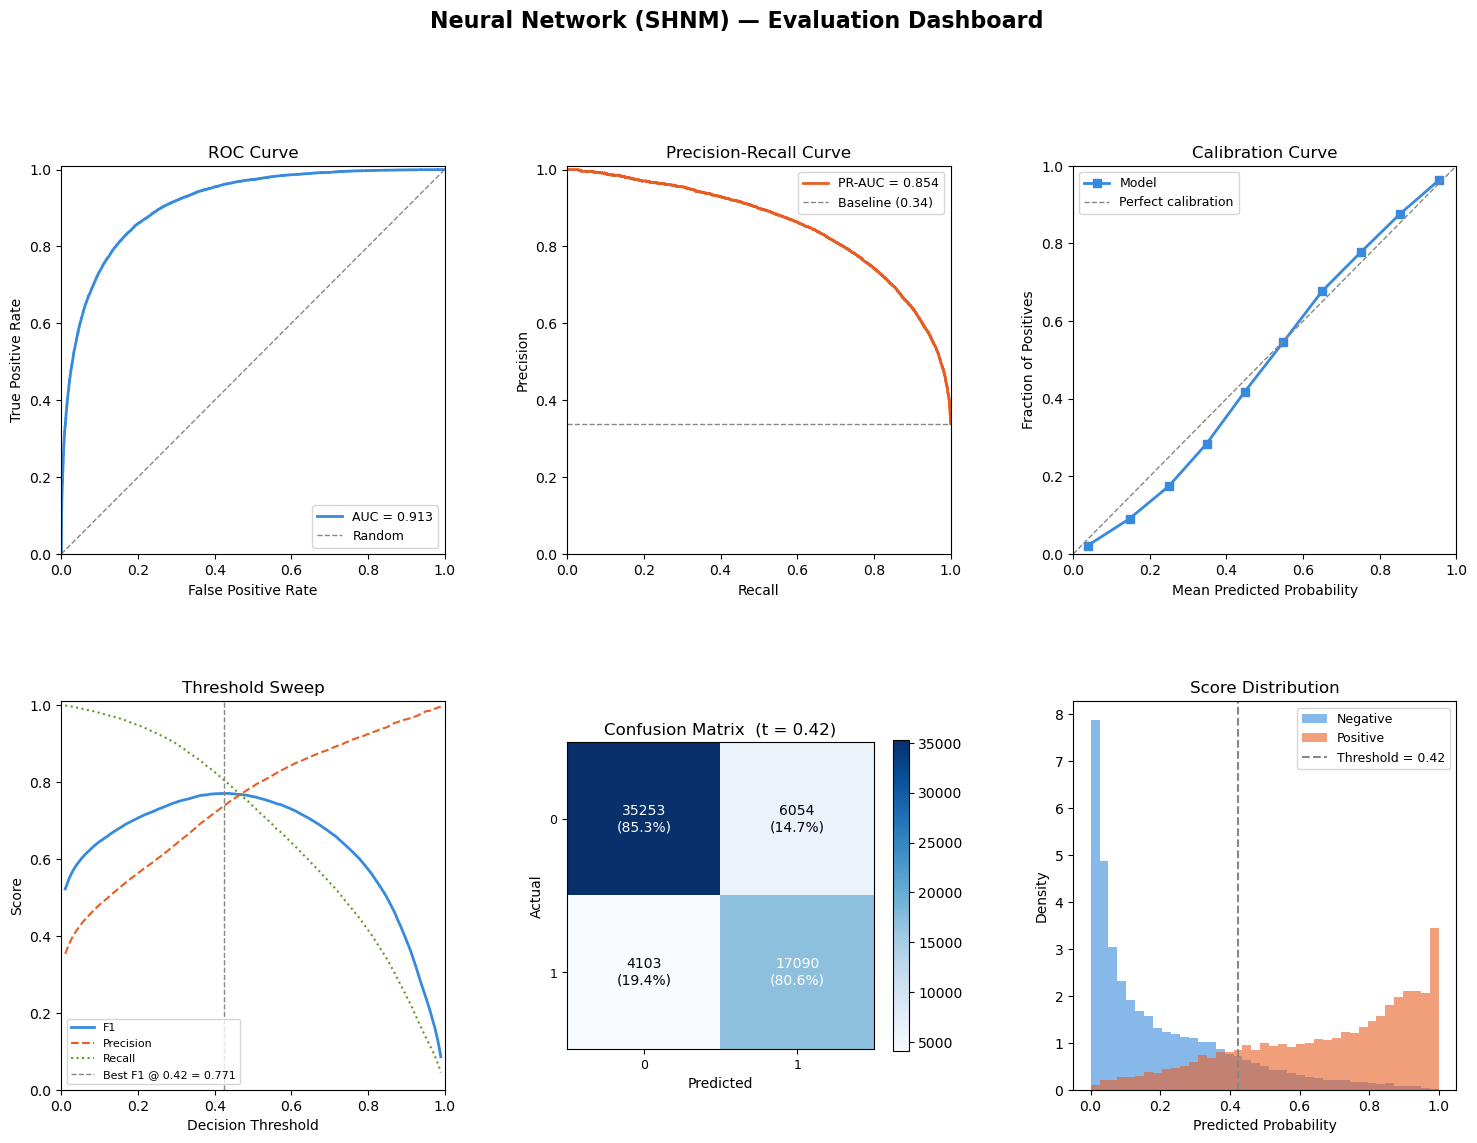


Plot saved → nn_shnm_evaluation_dashboard.png


In [ ]:
### Eval SHNM model

y_prob_shnm = best_model_shnm.predict(X_test_scaled, batch_size = 4096).flatten()

roc_auc_shnm = roc_auc_score(y_test, y_prob_shnm)
pr_auc_shnm = average_precision_score(y_test, y_prob_shnm)

print(f"Test ROC-AUC : {roc_auc_shnm:.4f}")
print(f"Test PR-AUC  : {pr_auc_shnm:.4f}")

thresholds = np.linspace(0.01, 0.99, 200)
f1_scores = [f1_score(y_test, y_prob_shnm >= t, zero_division = 0) for t in thresholds]
prec_scores = [precision_score(y_test, y_prob_shnm >= t, zero_division = 0) for t in thresholds]
rec_scores = [recall_score(y_test,    y_prob_shnm >= t, zero_division = 0) for t in thresholds]

best_thresh_idx = int(np.argmax(f1_scores))
best_thresh = thresholds[best_thresh_idx]
y_pred = (y_prob_shnm >= best_thresh).astype(int)

print(f"\nBest threshold (max F1): {best_thresh:.3f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, zero_division = 0):.4f}")
print(f"Recall : {recall_score(y_test, y_pred, zero_division = 0):.4f}")
print(f"F1 : {f1_score(y_test, y_pred, zero_division = 0):.4f}")
print(f"ROC AUC : {roc_auc_shnm:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob_shnm)
precision, recall, _ = precision_recall_curve(y_test, y_prob_shnm)
frac_pos, mean_pred  = calibration_curve(y_test, y_prob_shnm, n_bins = 10)
cm = confusion_matrix(y_test, y_pred)

### DEFINE DB LAYOUT
fig = plt.figure(figsize = (18, 12))
fig.suptitle("Neural Network (SHNM) - Evaluation Dashboard", fontsize = 16, fontweight = "bold", y = 1.01)
gs = gridspec.GridSpec(2, 3, figure = fig, hspace = 0.38, wspace = 0.32)

ax1 = fig.add_subplot(gs[0, 0])   # ROC
ax2 = fig.add_subplot(gs[0, 1])   # PR curve
ax3 = fig.add_subplot(gs[0, 2])   # Calibration
ax4 = fig.add_subplot(gs[1, 0])   # Threshold sweep
ax5 = fig.add_subplot(gs[1, 1])   # Confusion matrix
ax6 = fig.add_subplot(gs[1, 2])   # Score distribution

BLUE   = "#378ADD"
ORANGE = "#E85D24"
GREEN  = "#639922"
GRAY   = "#888780"

### ROC CURVE
ax1.plot(fpr, tpr, color = BLUE, lw = 2, label = f"AUC = {roc_auc_shnm:.3f}")
ax1.plot([0, 1], [0, 1], "--", color = GRAY, lw = 1, label = "Random")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.legend(loc = "lower right", fontsize = 9)
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.01])

### PREC-RECALL CURVE
baseline = float(y_test.mean())
ax2.plot(recall, precision, color = ORANGE, lw = 2, label = f"PR-AUC = {pr_auc_shnm:.3f}")
ax2.axhline(baseline, color = GRAY, lw = 1, linestyle="--", label = f"Baseline ({baseline:.2f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend(loc = "upper right", fontsize = 9)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.01])

# CALIBRATION CURVE
ax3.plot(mean_pred, frac_pos, "s-", color = BLUE, lw = 2, label = "Model")
ax3.plot([0, 1], [0, 1], "--", color = GRAY, lw = 1, label = "Perfect calibration")
ax3.set_xlabel("Mean Predicted Probability")
ax3.set_ylabel("Fraction of Positives")
ax3.set_title("Calibration Curve")
ax3.legend(loc = "upper left", fontsize = 9)
ax3.set_xlim([0, 1]); ax3.set_ylim([0, 1])

# THRESH SWEEP
ax4.plot(thresholds, f1_scores,   color = BLUE,   lw = 2, label="F1")
ax4.plot(thresholds, prec_scores, color = ORANGE, lw = 1.5, linestyle="--", label = "Precision")
ax4.plot(thresholds, rec_scores,  color = GREEN,  lw = 1.5, linestyle=":",  label = "Recall")
ax4.axvline(best_thresh, color = GRAY, lw = 1, linestyle = "--", label = f"Best F1 @ {best_thresh:.2f} = {f1_scores[best_thresh_idx]:.3f}")
ax4.set_xlabel("Decision Threshold")
ax4.set_ylabel("Score")
ax4.set_title("Threshold Sweep")
ax4.legend(fontsize = 8)
ax4.set_xlim([0, 1]); ax4.set_ylim([0, 1.01])

### CONFUSTION MATRIX
im = ax5.imshow(cm, interpolation = "nearest", cmap = "Blues")
fig.colorbar(im, ax = ax5, shrink = 0.8)
classes = [str(c) for c in sorted(np.unique(y_test))]
tick_marks = np.arange(len(classes))
ax5.set_xticks(tick_marks); ax5.set_xticklabels(classes, fontsize = 9)
ax5.set_yticks(tick_marks); ax5.set_yticklabels(classes, fontsize = 9)
ax5.set_xlabel("Predicted"); ax5.set_ylabel("Actual")
ax5.set_title(f"Confusion Matrix  (t = {best_thresh:.2f})")
cm_norm = cm.astype(float) / cm.sum(axis = 1, keepdims = True)
for i in range(2):
    for j in range(2):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax5.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.1%})", ha = "center", va = "center", color = color, fontsize = 10)

### SCORE DISTRIBUTION
neg_probs = y_prob_shnm[y_test == 0]
pos_probs = y_prob_shnm[y_test == 1]
bins = np.linspace(0, 1, 40)
ax6.hist(neg_probs, bins = bins, alpha = 0.6, color = BLUE,   density = True, label = "Negative")
ax6.hist(pos_probs, bins = bins, alpha = 0.6, color = ORANGE, density = True, label = "Positive")
ax6.axvline(best_thresh, color = GRAY, lw = 1.5, linestyle = "--", label=f"Threshold = {best_thresh:.2f}")
ax6.set_xlabel("Predicted Probability")
ax6.set_ylabel("Density")
ax6.set_title("Score Distribution")
ax6.legend(fontsize = 9)

plt.savefig("nn_shnm_evaluation_dashboard.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("\nPlot saved → nn_shnm_evaluation_dashboard.png")

In [29]:
best_model_shnm.save("best_model_shnm_NN.keras")
# best_model_shnm = keras.models.load_model("best_model_shnm.keras") # Load model to skip retraining

### SHAP/LIME Interpretability for NN Models

c:\Users\nicho\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\nicho\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\nicho\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:153: UserWarning: You have provided over 5k background samples! For better performance consider using smaller random sample.
  warnings.warn(
c:\Users\nicho\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(25000, 32))']
  

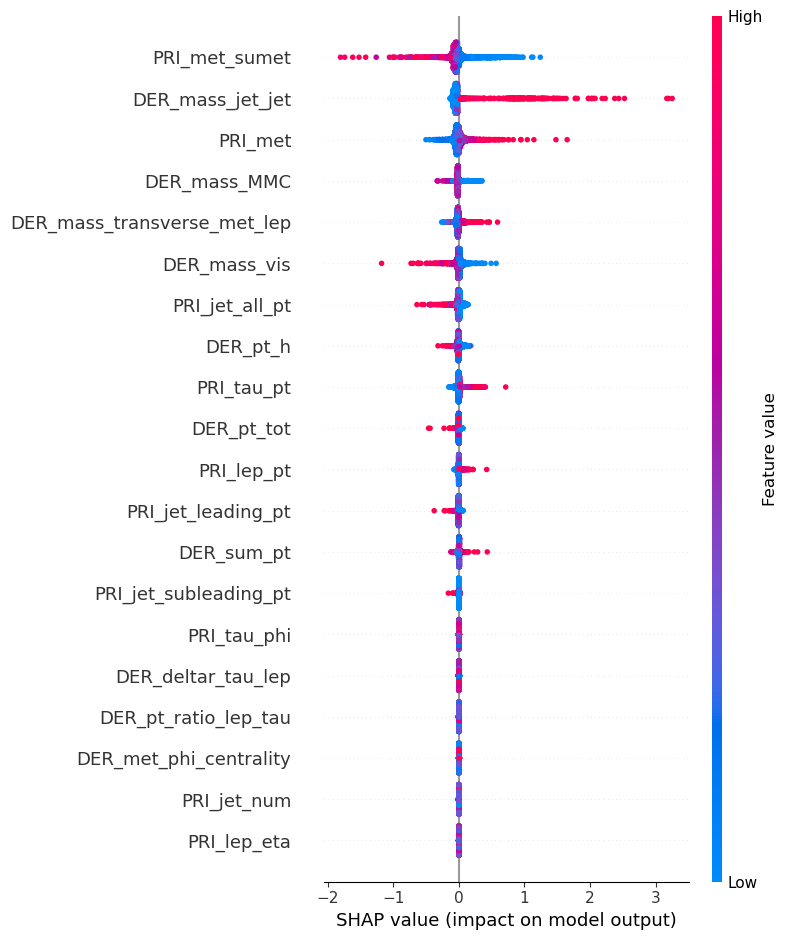

In [11]:
import shap
import torch
from sklearn.utils import resample

best_model = keras.saving.load_model("best_model_NN.keras")

_, idx = np.unique(y_train, return_index=False)

background = resample(
    X_train,
    n_samples=25000,
    stratify=y_train,
    random_state=2026
)

explainer = shap.DeepExplainer(best_model, background.to_numpy())
shap_values = explainer.shap_values(X_test[:5000].to_numpy())

sv = np.squeeze(shap_values)

shap.summary_plot(sv, X_test[:5000].to_numpy(), feature_names=X_train.columns.tolist())

# Double Descent

- The code below was done before the NN experimentation above
- Due to the insane training times, the code below will be left to show the approach used in attempt to replicate the phenomenon

In [9]:
def build_width_model(input_dim, width):

    model = keras.Sequential([
        keras.layers.Dense(width, activation="relu", input_shape=(input_dim,)),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# widths = [4, 8, 16, 32, 64, 128, 256, 512, 1024] # Increasing NN widths to cross interpolation threshold
widths = [2**i for i in range(20)]
widths

[1,
 2,
 4,
 8,
 16,
 32,
 64,
 128,
 256,
 512,
 1024,
 2048,
 4096,
 8192,
 16384,
 32768,
 65536,
 131072,
 262144,
 524288]

In [11]:
import time

# Train model for each width and record train/test errors
train_errors = []
test_errors = []
train_times = []

for width in widths:

    print(f"Training width: {width}")

    model = build_width_model(X_train_scaled.shape[1], width)

    start_time = time.time()  # Start timer

    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=100,
        batch_size=512,
        verbose=0
    )

    end_time = time.time()  # End timer
    runtime = end_time - start_time
    train_times.append(runtime)

    print(f"Runtime: {runtime:.2f} seconds")

    # Training predictions
    train_prob = model.predict(X_train_scaled, verbose=0).flatten()
    train_pred = (train_prob >= 0.5).astype(int)

    # Test predictions
    test_prob = model.predict(X_test_scaled, verbose=0).flatten()
    test_pred = (test_prob >= 0.5).astype(int)

    train_error = 1 - np.mean(train_pred == y_train)
    test_error = 1 - np.mean(test_pred == y_test)

    train_errors.append(train_error)
    test_errors.append(test_error)

Training width: 1


c:\Users\nicho\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Runtime: 43.12 seconds
Training width: 2
Runtime: 43.17 seconds
Training width: 4
Runtime: 42.52 seconds
Training width: 8
Runtime: 45.10 seconds
Training width: 16
Runtime: 42.46 seconds
Training width: 32
Runtime: 43.49 seconds
Training width: 64
Runtime: 44.83 seconds
Training width: 128
Runtime: 47.96 seconds
Training width: 256
Runtime: 50.77 seconds
Training width: 512
Runtime: 58.18 seconds
Training width: 1024
Runtime: 77.91 seconds
Training width: 2048
Runtime: 112.46 seconds
Training width: 4096
Runtime: 164.31 seconds
Training width: 8192
Runtime: 238.39 seconds
Training width: 16384
Runtime: 469.69 seconds
Training width: 32768
Runtime: 996.80 seconds
Training width: 65536
Runtime: 2084.49 seconds
Training width: 131072
Runtime: 3911.16 seconds
Training width: 262144
Runtime: 8469.34 seconds
Training width: 524288
Runtime: 17014.36 seconds


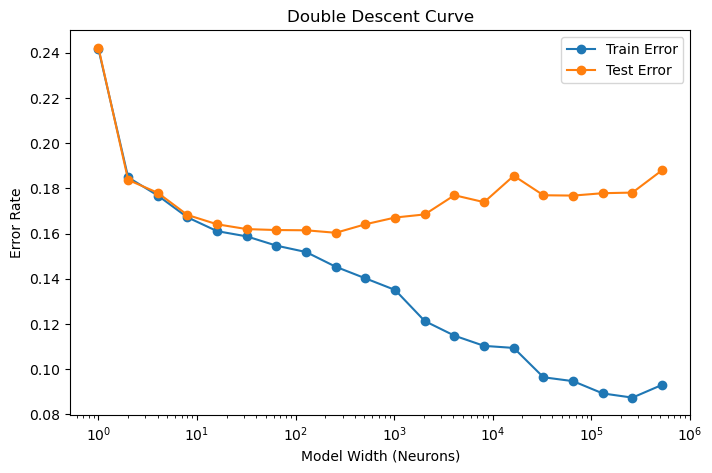

In [12]:
# Plot and observe for double descent

plt.figure(figsize=(8,5))

plt.plot(widths, train_errors, label="Train Error", marker="o")
plt.plot(widths, test_errors, label="Test Error", marker="o")

plt.xscale("log")

plt.xlabel("Model Width (Neurons)")
plt.ylabel("Error Rate")
plt.title("Double Descent Curve")
plt.legend()

plt.show()